In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report,roc_curve,roc_auc_score
)


In [2]:
file_path = 'dataset diabetes (1).csv'
df = pd.read_csv(file_path)

In [3]:
print(df.head())


   Jenis Kelamin  Kehamilan  Glukosa  Tekanan Darah  Ketebalan Kulit  Insulin  \
0              0          6      148             72               35        0   
1              0          1       85             66               29        0   
2              0          8      183             64                0        0   
3              0          1       89             66               23       94   
4              1          0      137             40               35      168   

    BMI  DiabetesPedigreeFunction  Usia  Outcome  
0  33.6                     0.627    50        1  
1  26.6                     0.351    31        0  
2  23.3                     0.672    32        1  
3  28.1                     0.167    21        0  
4  43.1                     2.288    33        1  


In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 11376 entries, 0 to 11375
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Jenis Kelamin             11376 non-null  int64  
 1   Kehamilan                 11376 non-null  int64  
 2   Glukosa                   11376 non-null  int64  
 3   Tekanan Darah             11376 non-null  int64  
 4   Ketebalan Kulit           11376 non-null  int64  
 5   Insulin                   11376 non-null  int64  
 6   BMI                       11376 non-null  float64
 7   DiabetesPedigreeFunction  11376 non-null  float64
 8   Usia                      11376 non-null  int64  
 9   Outcome                   11376 non-null  int64  
dtypes: float64(2), int64(8)
memory usage: 888.9 KB
None


In [5]:
print(df.describe())

       Jenis Kelamin     Kehamilan       Glukosa  Tekanan Darah  \
count   11376.000000  11376.000000  11376.000000   11376.000000   
mean        0.128165      4.437412    127.377022      70.979430   
std         0.334288      3.581018     35.374612      17.722042   
min         0.000000      0.000000      0.000000       0.000000   
25%         0.000000      1.000000    100.000000      65.000000   
50%         0.000000      4.000000    123.000000      74.000000   
75%         0.000000      7.000000    151.000000      80.000000   
max         1.000000     17.000000    199.000000     122.000000   

       Ketebalan Kulit       Insulin           BMI  DiabetesPedigreeFunction  \
count     11376.000000  11376.000000  11376.000000              11376.000000   
mean         22.387746     91.829641     33.146607                  0.467703   
std          15.325424    118.065475      7.730432                  0.306595   
min           0.000000      0.000000      0.000000                  0.078000

In [6]:
cols_invalid_zero = [
'Glukosa',
'Tekanan Darah',
'Ketebalan Kulit',
'Insulin',
'BMI'
]


In [7]:
for col in cols_invalid_zero:
    if col in df.columns:
        df[col] = df[col].replace(0, np.nan)


In [8]:
print(df.isnull().sum())


Jenis Kelamin                  0
Kehamilan                      0
Glukosa                       64
Tekanan Darah                409
Ketebalan Kulit             2845
Insulin                     5366
BMI                          130
DiabetesPedigreeFunction       0
Usia                           0
Outcome                        0
dtype: int64


In [9]:
for col in cols_invalid_zero:
    df[col] = df[col].fillna(df[col].median())

In [10]:
print(df.isnull().sum())

Jenis Kelamin               0
Kehamilan                   0
Glukosa                     0
Tekanan Darah               0
Ketebalan Kulit             0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Usia                        0
Outcome                     0
dtype: int64


In [11]:
print(df['Outcome'].value_counts())

Outcome
0    5749
1    5627
Name: count, dtype: int64


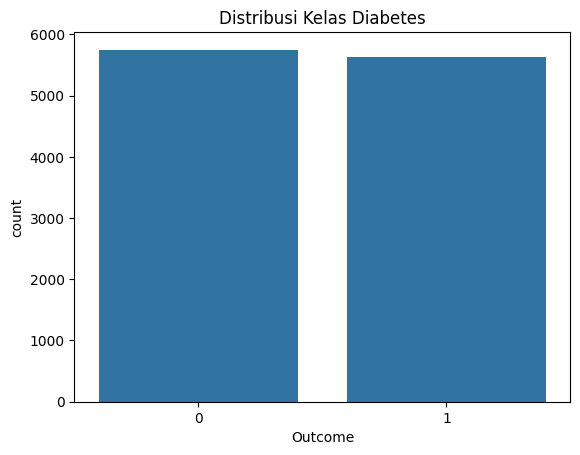

In [12]:
sns.countplot(x='Outcome', data=df)
plt.title('Distribusi Kelas Diabetes')
plt.show()


In [13]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X,y,
test_size=0.2,
random_state=42,
stratify=y
)

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': [1, 0.1, 0.01],
    'kernel': ['rbf']
}

grid = GridSearchCV(
    SVC(probability=True),
    param_grid,
    refit=True,
    cv=3,
    verbose=2
)

grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)

svm_model = grid.best_estimator_

Fitting 3 folds for each of 9 candidates, totalling 27 fits
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   4.9s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   4.6s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   4.2s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   3.6s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   3.6s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   3.7s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   4.1s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   4.0s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   4.0s
[CV] END ...........................C=1, gamma=1, kernel=rbf; total time=   1.9s
[CV] END ...........................C=1, gamma=1, kernel=rbf; total time=   2.0s
[CV] END ...........................C=1, gamma=1,

In [17]:
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

In [18]:
rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=5, 
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)


In [19]:
acc_svm = accuracy_score(y_test, y_pred_svm)
acc_rf = accuracy_score(y_test, y_pred_rf)

print('Accuracy SVM :', acc_svm)
print('Accuracy RF :', acc_rf)


Accuracy SVM : 0.9806678383128296
Accuracy RF : 0.8611599297012302


In [20]:
precision_svm = precision_score(y_test, y_pred_svm)
precision_rf = precision_score(y_test, y_pred_rf)

print('precision SVM :', precision_svm)
print('precision RF :', precision_rf)


precision SVM : 0.9882671480144405
precision RF : 0.8729281767955801


In [21]:
recall_svm = recall_score(y_test, y_pred_svm)
recall_rf = recall_score(y_test, y_pred_rf)

print('recall SVM :', recall_svm)
print('recall RF :', recall_rf)

recall SVM : 0.9724689165186501
recall RF : 0.8419182948490231


In [22]:
f1_svm = f1_score(y_test, y_pred_svm)
f1_rf = f1_score(y_test, y_pred_rf)

print('F1 Score SVM :', f1_svm)
print('F1 Score RF :', f1_rf)

F1 Score SVM : 0.9803043867502238
F1 Score RF : 0.8571428571428571


In [23]:
cm_svm = confusion_matrix(y_test, y_pred_svm)
cm_rf = confusion_matrix(y_test, y_pred_rf)

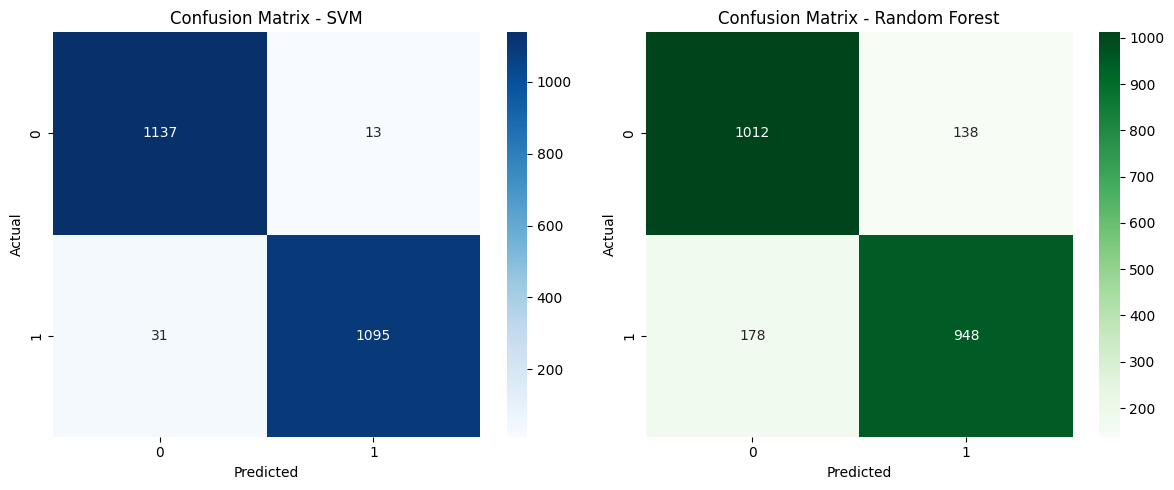

In [24]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - SVM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.subplot(1,2,2)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


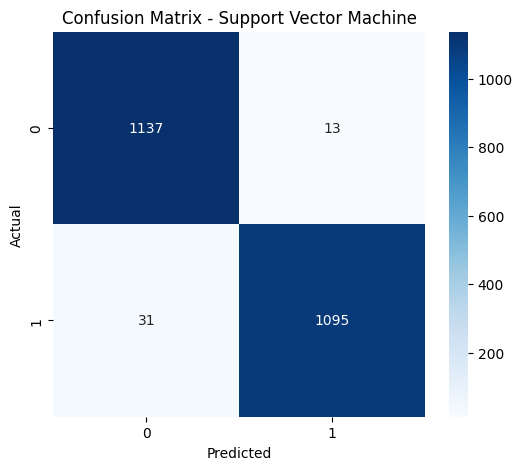

In [25]:
plt.figure(figsize=(6,5))
sns.heatmap(cm_svm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title('Confusion Matrix - Support Vector Machine')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

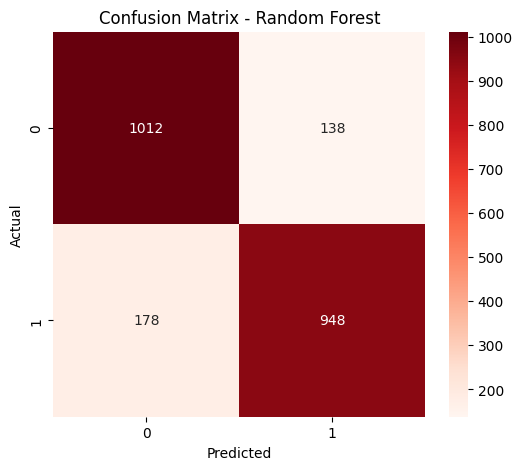

In [26]:
plt.figure(figsize=(6,5))
sns.heatmap(cm_rf,
            annot=True,
            fmt='d',
            cmap='Reds')

plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [27]:
svm_probs = svm_model.predict_proba(X_test_scaled)[:,1]
rf_probs = rf_model.predict_proba(X_test)[:,1]


fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)

In [28]:
auc_svm = roc_auc_score(y_test, svm_probs)
auc_rf = roc_auc_score(y_test, rf_probs)

print("AUC SVM :", auc_svm)
print("AUC RF :", auc_rf)

AUC SVM : 0.9797640744459031
AUC RF : 0.9431585450613947


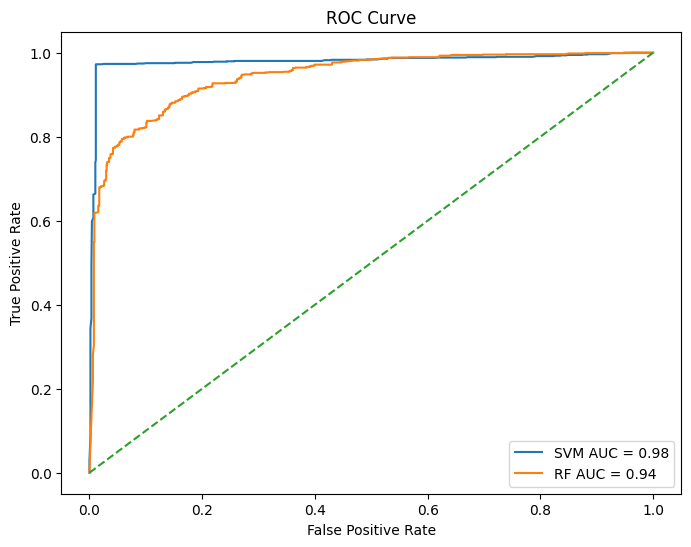

In [29]:
plt.figure(figsize=(8,6))
plt.plot(fpr_svm, tpr_svm, label=f'SVM AUC = {auc_svm:.2f}')
plt.plot(fpr_rf , tpr_rf, label=f'RF AUC = {auc_rf:.2f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


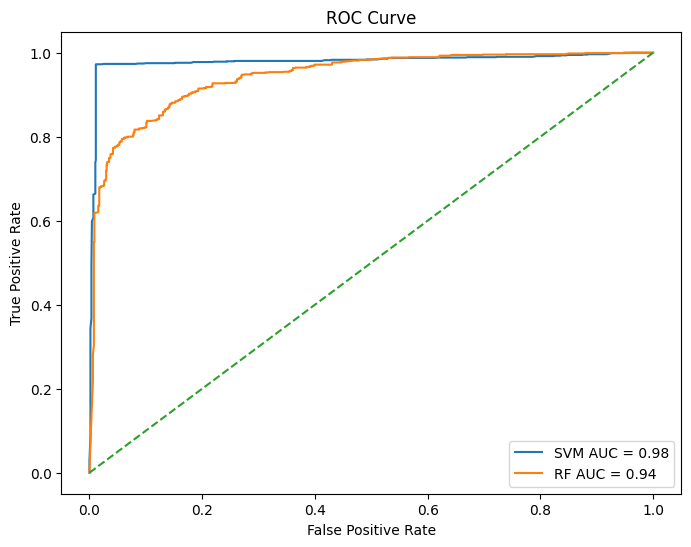

In [30]:
import matplotlib.pyplot as plt

fig_roc, ax = plt.subplots(figsize=(8,6))

ax.plot(fpr_svm, tpr_svm, label=f'SVM AUC = {auc_svm:.2f}')
ax.plot(fpr_rf, tpr_rf, label=f'RF AUC = {auc_rf:.2f}')
ax.plot([0,1], [0,1], linestyle='--')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')

ax.legend()

In [31]:
acc_svm = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm)
rec_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

print("=== Support Vector Machine ===")
print("Accuracy :", acc_svm)
print("Precision:", prec_svm)
print("Recall   :", rec_svm)
print("F1-score :", f1_svm)

=== Support Vector Machine ===
Accuracy : 0.9806678383128296
Precision: 0.9882671480144405
Recall   : 0.9724689165186501
F1-score : 0.9803043867502238


In [32]:
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("=== Random Forest ===")
print("Accuracy :", acc_rf)
print("Precision:", prec_rf)
print("Recall   :", rec_rf)
print("F1-score :", f1_rf)

=== Random Forest ===
Accuracy : 0.8611599297012302
Precision: 0.8729281767955801
Recall   : 0.8419182948490231
F1-score : 0.8571428571428571


In [33]:
models = ['SVM', 'Random Forest']

precisions = [precision_svm, precision_rf]
recalls = [recall_svm, recall_rf]
f1_scores = [f1_svm, f1_rf]


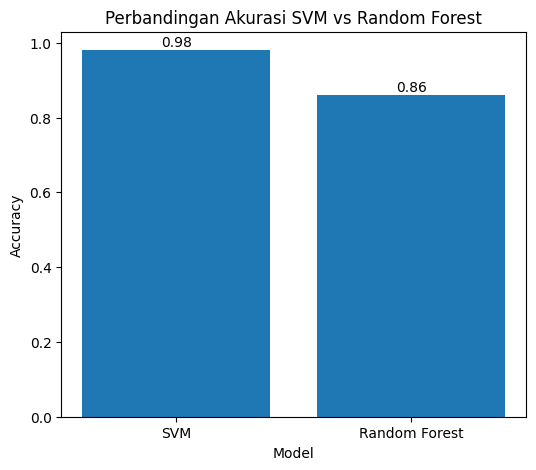

In [34]:
models = ['SVM', 'Random Forest']
accuracies = [acc_svm, acc_rf]
plt.figure(figsize=(6,5))
plt.bar(models, accuracies)
plt.title('Perbandingan Akurasi SVM vs Random Forest')
plt.xlabel('Model')
plt.ylabel('Accuracy')
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f'{v:.2f}', ha='center')
plt.show()


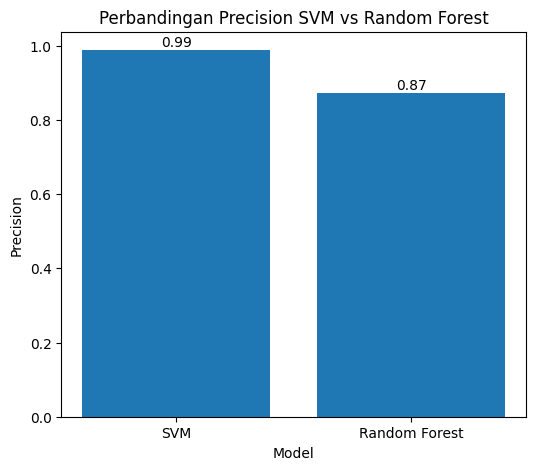

In [35]:
plt.figure(figsize=(6,5))
plt.bar(models, precisions)

plt.title('Perbandingan Precision SVM vs Random Forest')
plt.xlabel('Model')
plt.ylabel('Precision')

for i, v in enumerate(precisions):
    plt.text(i, v + 0.01, f'{v:.2f}', ha='center')

plt.show()

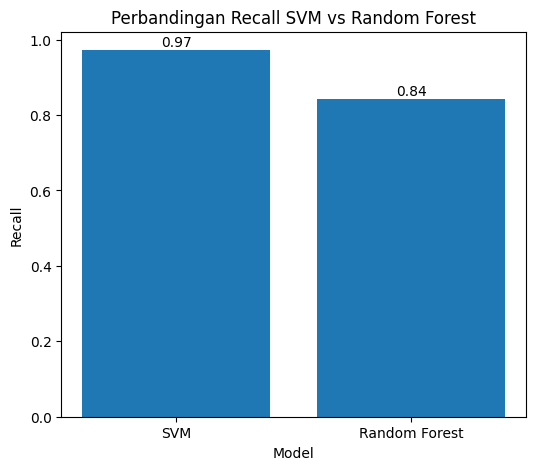

In [36]:
plt.figure(figsize=(6,5))
plt.bar(models, recalls)

plt.title('Perbandingan Recall SVM vs Random Forest')
plt.xlabel('Model')
plt.ylabel('Recall')

for i, v in enumerate(recalls):
    plt.text(i, v + 0.01, f'{v:.2f}', ha='center')

plt.show()


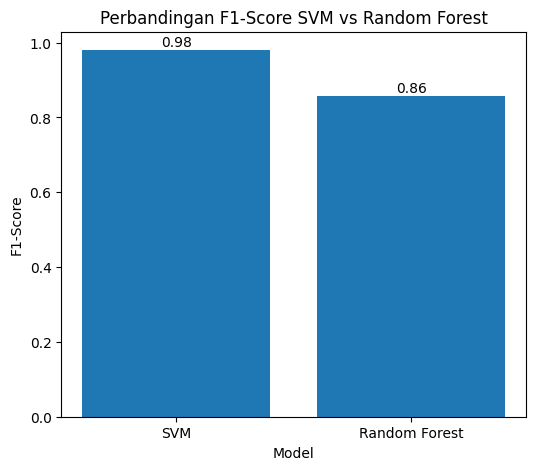

In [37]:
plt.figure(figsize=(6,5))
plt.bar(models, f1_scores)

plt.title('Perbandingan F1-Score SVM vs Random Forest')
plt.xlabel('Model')
plt.ylabel('F1-Score')

for i, v in enumerate(f1_scores):
    plt.text(i, v + 0.01, f'{v:.2f}', ha='center')

plt.show()

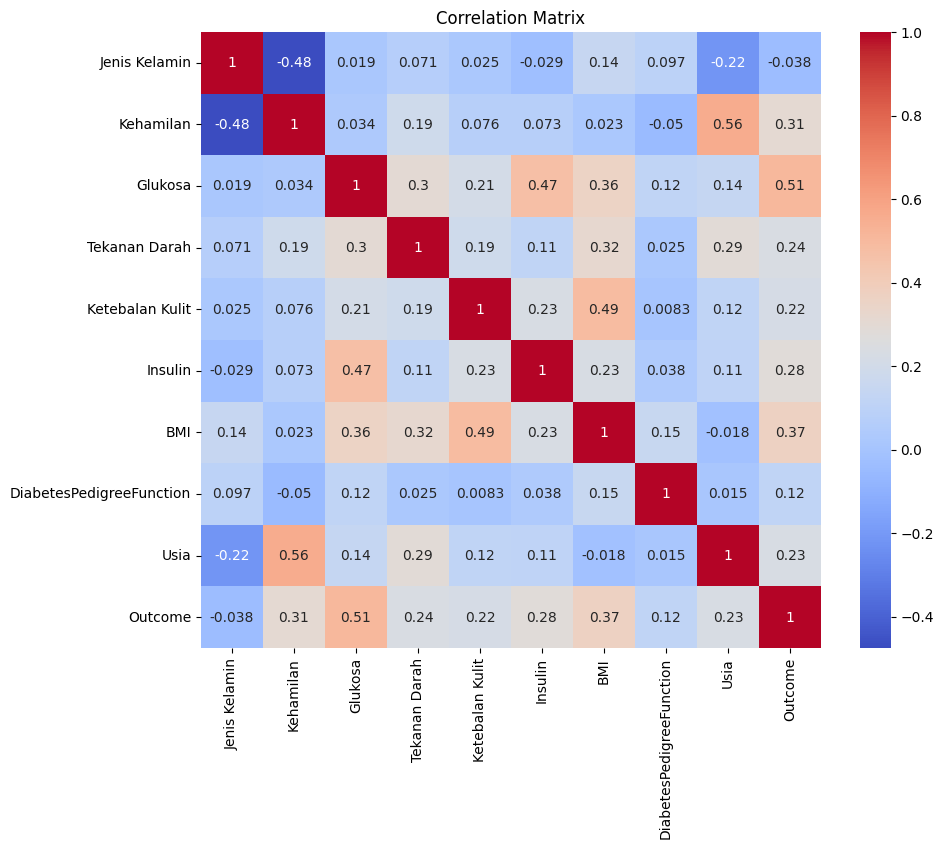

In [38]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm')

plt.title('Correlation Matrix')
plt.show()

In [39]:
import joblib

joblib.dump(svm_model, "svm_model.pkl")
joblib.dump(rf_model, "rf_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [40]:
df.to_csv("dataset_bersih.csv", index=False)